In [1]:
from pathlib import Path

import pandas as pd

file_path = Path.cwd() / "Trust force_parametersweep_run1.csv"
if not file_path.is_file():
    raise FileNotFoundError(f"CSV file not found: {file_path.resolve()}")

df = pd.read_csv(file_path)

print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns")
df.head()

Loaded 6 rows and 72 columns


,Gap_Axial_trust,Thrust Force,Gap_Axial_trust.1,Thrust Force.1,Gap_Axial_trust.2,Thrust Force.2,Gap_Axial_trust.3,Thrust Force.3,Gap_Axial_trust.4,Thrust Force.4,...,Gap_Axial_trust.31,Thrust Force.31,Gap_Axial_trust.32,Thrust Force.32,Gap_Axial_trust.33,Thrust Force.33,Gap_Axial_trust.34,Thrust Force.34,Gap_Axial_trust.35,Thrust Force.35
0,0,-19.090099,0,-21.183506,0,-23.022821,0,-24.615312,0,-26.112955,...,0,-4.445266,0,-4.474788,0,-4.448922,0,-4.359971,0,-4.354929
1,1,-18.509233,1,-20.910979,1,-23.058824,1,-24.932248,1,-26.671112,...,1,-6.432452,1,-6.460702,1,-6.390220,1,-6.275404,1,-6.244527
2,2,-17.328330,2,-19.899667,2,-22.277361,2,-24.396687,2,-26.490098,...,2,-9.061171,2,-9.132384,2,-9.043702,2,-8.964795,2,-8.913248
3,3,-15.915997,3,-18.462860,3,-20.882431,3,-23.155747,3,-25.538244,...,3,-12.090127,3,-12.281702,3,-12.207440,3,-12.240647,3,-12.151401
4,4,-14.519549,4,-16.884424,4,-19.204939,4,-21.448365,4,-23.908889,...,4,-15.120146,4,-15.400517,4,-15.465113,4,-15.610905,4,-15.553314


In [2]:
import numpy as np
kapa = np.array([0.7, 0.78, 0.86, 0.94, 1.02, 1.1])
gap_axial_trust = np.array([0, 1, 2, 3, 4, 5])
magnet_height=np.array([6, 6.8, 7.6, 8.4, 9.2, 10])



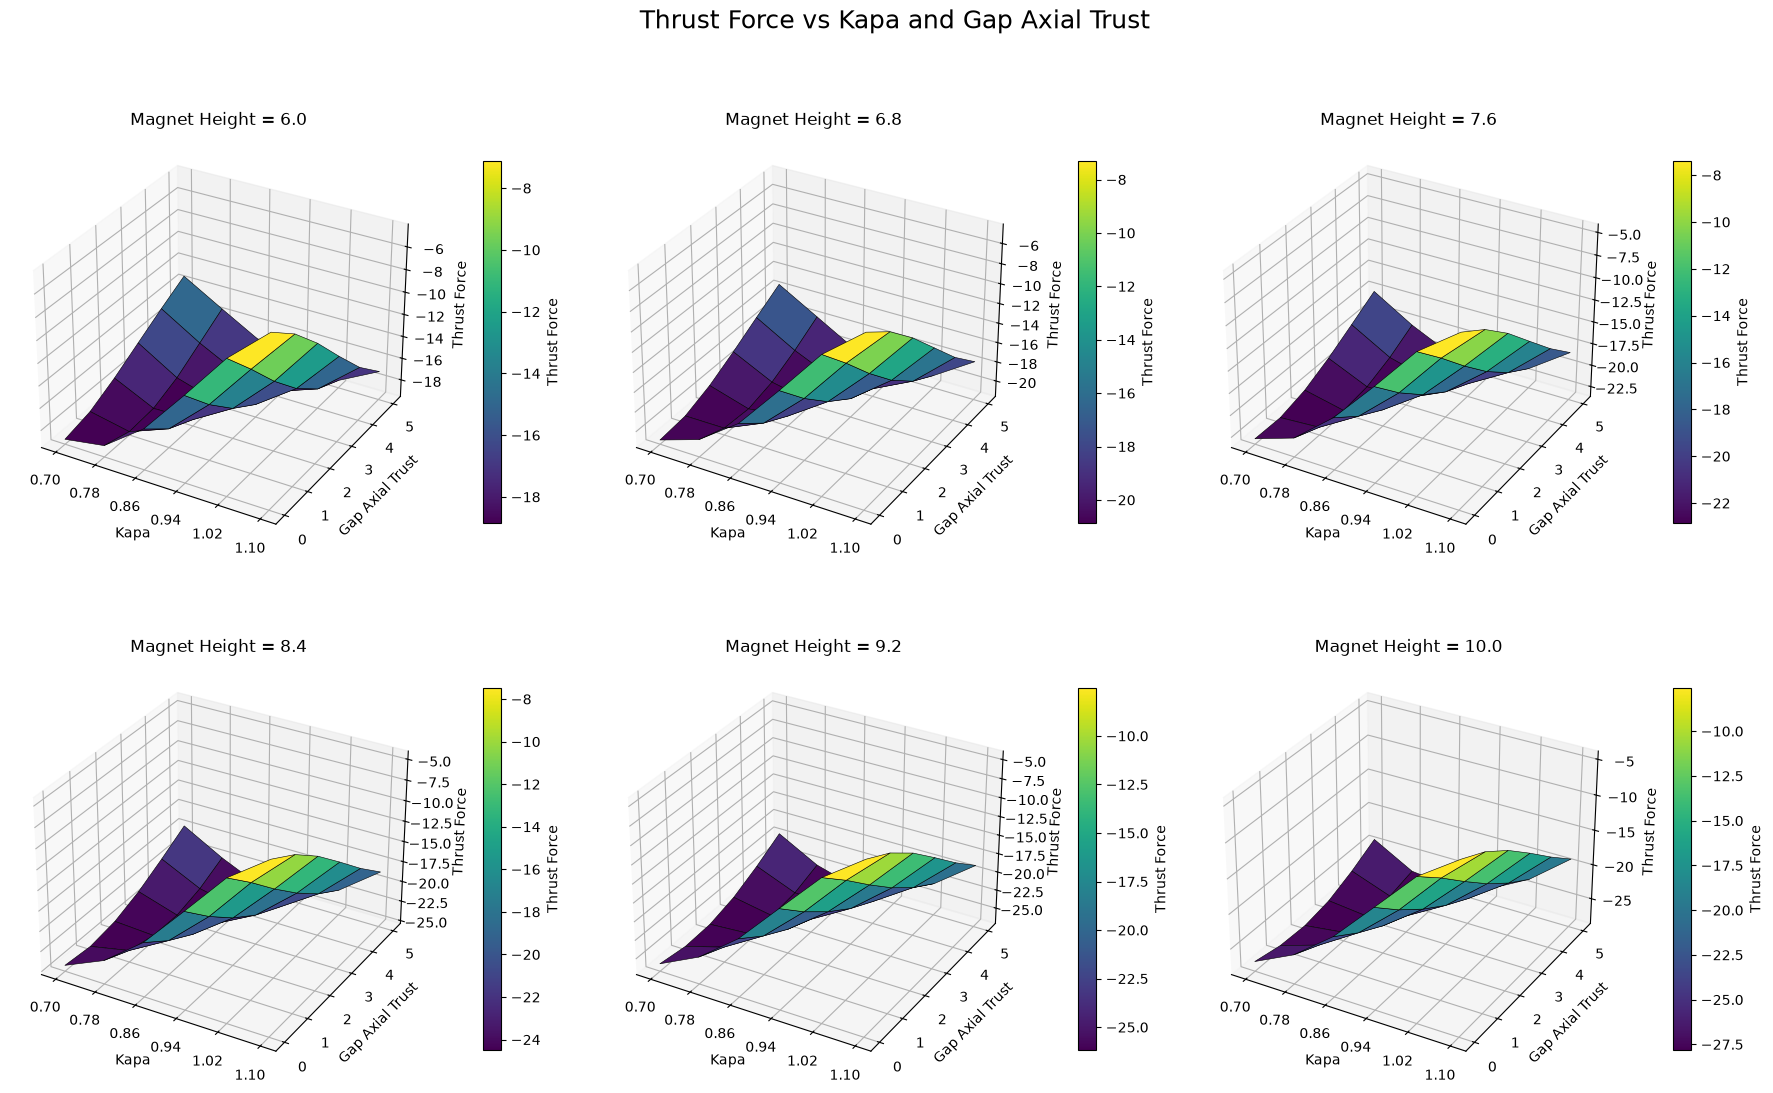

In [5]:
import matplotlib.pyplot as plt

# --------------------------------------------------
# 3. Create mesh for the 3D surface
#
# X = Kapa
# Y = Gap Axial Trust
# Z = Thrust Force
# --------------------------------------------------

X, Y = np.meshgrid(kapa, gap_axial_trust)


# --------------------------------------------------
# 4. Create six 3D plots
# --------------------------------------------------

fig = plt.figure(figsize=(18, 12))

for h_idx, height in enumerate(magnet_height):

    # Matrix:
    #
    # rows    -> Gap Axial Trust
    # columns -> Kapa
    #
    # Shape = 6 x 6

    Z = np.zeros((len(gap_axial_trust), len(kapa)))

    for k_idx in range(len(kapa)):

        # --------------------------------------------------
        # CSV organization:
        #
        # kapa 0.70:
        #   height 6
        #   height 6.8
        #   height 7.6
        #   ...
        #
        # kapa 0.78:
        #   height 6
        #   height 6.8
        #   ...
        # --------------------------------------------------

        case_index = k_idx * len(magnet_height) + h_idx

        # Every case has two columns:
        # 0 -> Gap Axial Trust
        # 1 -> Thrust Force

        gap_column_index = case_index * 2
        thrust_column_index = gap_column_index + 1

        # Extract thrust force
        Z[:, k_idx] = df.iloc[:, thrust_column_index].to_numpy()

    # --------------------------------------------------
    # Create subplot
    # --------------------------------------------------

    ax = fig.add_subplot(2, 3, h_idx + 1, projection="3d")

    surface = ax.plot_surface(
        X,
        Y,
        Z,
        cmap="viridis",
        edgecolor="black",
        linewidth=0.4
    )

    # Axis labels
    ax.set_xlabel("Kapa")
    ax.set_ylabel("Gap Axial Trust")
    ax.set_zlabel("Thrust Force")

    # Title
    ax.set_title(f"Magnet Height = {height}")

    # Show actual parameter values
    ax.set_xticks(kapa)
    ax.set_yticks(gap_axial_trust)

    # Color bar
    fig.colorbar(
        surface,
        ax=ax,
        shrink=0.6,
        pad=0.1,
        label="Thrust Force"
    )


# --------------------------------------------------
# 5. Final plot formatting
# --------------------------------------------------

fig.suptitle(
    "Thrust Force vs Kapa and Gap Axial Trust",
    fontsize=18
)

plt.tight_layout()

plt.savefig(
    "thrust_force_surface_plots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()